<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:110%; font-family:Pacifico; background-color:#0073e6; overflow:hidden"><b>LLM-Powered Sentiment Analysis and Customer Support for Olist</b></div>

<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:110%; font-family:Pacifico; background-color:#0073e6; overflow:hidden"><b> Part 1 - Business Problem </b></div>

**Business Problem - Business Problem with LLM + RAG on the Olist E-Commerce Dataset**

### Context

Olist processes thousands of e-commerce orders daily. Each order contains:

* **Purchase data** (price, freight, status, timestamps),
* **Customer and seller information** (location, ZIP code, state),
* **Product details** (categories, dimensions),
* **Satisfaction feedback** (review text, review scores).

The main business challenge is to **quickly understand customer feedback** in order to:

1. Improve **delivery logistics**,
2. Detect **problematic products**,
3. Assist the **customer service team** with personalized responses.

### Problem Definition

**How can we leverage a Large Language Model (Sabia-7B) with RAG (Retrieval-Augmented Generation) to automatically analyze customer reviews, generate insights, and support automated customer service responses?**

### Technical Approach

### 1. RAG Pipeline

* **Knowledge Base**: index dataset columns (`review_comment_message`, `review_score`, `order_status`, `delivery times`, `customer_city`, `seller_state`).
* Create embeddings (e.g., SentenceTransformers, FAISS/Weaviate/Chroma).
* The **Sabia-7B LLM** retrieves context via RAG:

  * Review text,
  * Order/delivery/product details,
  * Similar past complaints.

### 2. Prompt Engineering

Example **structured prompt**:

```
You are a customer support assistant at Olist.
Context: 
- Order: {order_id}, Status: {order_status}, Delivered: {order_delivered_customer_date}, Estimated: {order_estimated_delivery_date}
- Product: {product_id}, Category: {product_category}
- Customer: {customer_city}/{customer_state}
- Review score: {review_score}/5
- Review: "{review_comment_message}"

Task:
1. Identify the sentiment (positive, neutral, negative).
2. Explain the main cause of satisfaction or dissatisfaction.
3. Generate a polite, personalized response to the customer.
```

### 3. Business Metrics

* **Sentiment classification accuracy** (LLM vs. baseline ML).
* **Response time reduction** (automated vs. manual service).
* **Impact on NPS / satisfaction** (via simulated empathetic and personalized replies).

### Example Outputs

**Review**: "The product arrived 10 days later than promised, very disappointing."

* **Sentiment**: Negative
* **Cause**: Late delivery
* **LLM Response**:
  "We sincerely apologize for the delivery delay. We are reviewing our logistics process to prevent this from happening again. As a token of appreciation, we would like to offer you a discount coupon on your next purchase."

### Justification

This business problem combines:

* **Classic NLP tasks** (sentiment analysis, classification),
* **LLM + RAG capabilities** (contextualized responses with order data),
* **Direct business value** (lower support costs, improved customer experience).

In [1]:
!pip install leia-br

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.0/130.0 kB 3.4 MB/s eta 0:00:00a 0:00:01


In [81]:
# Core Libraries
import random                     # Random number generation and sampling
import re                         # Regular expressions for text processing
import string                     # String utilities (punctuation, etc.)
from collections import Counter   # Count frequency of items

import numpy as np                # Numerical computing
import pandas as pd               # Data manipulation and analysis
import matplotlib.pyplot as plt   # Plotting library
from matplotlib.colors import LinearSegmentedColormap  # Custom colormaps
import seaborn as sns             # Statistical data visualization
from tqdm import tqdm             # Progress bar for loops

# NLP & Text Processing
import nltk                       # Natural Language Toolkit
from nltk.corpus import stopwords # Stopword list for text preprocessing
from nltk.tokenize import word_tokenize  # Tokenizer
from nltk import ngrams           # N-gram generation
from wordcloud import WordCloud   # Word cloud visualization
from LeIA import SentimentIntensityAnalyzer  # Sentiment analysis (Portuguese)

# Machine Learning (Scikit-learn)
from sklearn.linear_model import LogisticRegression  # Logistic regression model
from sklearn.model_selection import train_test_split # Train/test split
from sklearn.preprocessing import StandardScaler     # Feature scaling
from sklearn.metrics import (                        # Model evaluation metrics
    classification_report,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, accuracy_score

# Deep Learning / Transformers
import torch                      # PyTorch deep learning library
from transformers import (        # Hugging Face Transformers
    AutoTokenizer,
    AutoModel,
    AutoModelForCausalLM,
    pipeline,
)

# Visualization Config
%matplotlib inline                # Enable inline plotting in Jupyter notebooks

# Define a custom Seaborn color palette
colors = ["#26536f", "#3b96b7", "#749ca8", "#b6a98d", "#c78a4d", "#854927"]
sns.set_palette(colors)


UsageError: unrecognized arguments: # Enable inline plotting in Jupyter notebooks


<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:110%; font-family:Pacifico; background-color:#0073e6; overflow:hidden"><b> Part 2 - Database </b></div>

In [3]:
# Reading files into DataFrames
df_items = pd.read_csv("/kaggle/input/brazilian-ecommerce/olist_order_items_dataset.csv")
df_reviews = pd.read_csv("/kaggle/input/brazilian-ecommerce/olist_order_reviews_dataset.csv")
df_orders = pd.read_csv("/kaggle/input/brazilian-ecommerce/olist_orders_dataset.csv")
df_products = pd.read_csv("/kaggle/input/brazilian-ecommerce/olist_products_dataset.csv")
df_geolocation = pd.read_csv("/kaggle/input/brazilian-ecommerce/olist_geolocation_dataset.csv")
df_sellers = pd.read_csv("/kaggle/input/brazilian-ecommerce/olist_sellers_dataset.csv")
df_payments = pd.read_csv("/kaggle/input/brazilian-ecommerce/olist_order_payments_dataset.csv")
df_customers = pd.read_csv("/kaggle/input/brazilian-ecommerce/olist_customers_dataset.csv")
df_category = pd.read_csv("/kaggle/input/brazilian-ecommerce/product_category_name_translation.csv")

In [4]:
# Merging Dataframes
df = df_orders.merge(df_items, on='order_id', how='inner')

#
df = df.merge(df_payments, on='order_id', how='inner', validate='m:m')

#
df = df.merge(df_reviews, on='order_id', how='inner')
df = df.merge(df_products, on='product_id', how='inner')
df = df.merge(df_customers, on='customer_id', how='inner')
df = df.merge(df_sellers, on='seller_id', how='inner')

# 
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_length_cm,product_height_cm,product_width_cm,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,seller_zip_code_prefix,seller_city,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,19.0,8.0,13.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,9350,maua,SP
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,19.0,8.0,13.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,9350,maua,SP
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,19.0,8.0,13.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,9350,maua,SP
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,...,19.0,13.0,19.0,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,31570,belo horizonte,SP
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,...,24.0,19.0,21.0,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,14840,guariba,SP


In [5]:
df.shape

(117329, 39)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117329 entries, 0 to 117328
Data columns (total 39 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       117329 non-null  object 
 1   customer_id                    117329 non-null  object 
 2   order_status                   117329 non-null  object 
 3   order_purchase_timestamp       117329 non-null  object 
 4   order_approved_at              117314 non-null  object 
 5   order_delivered_carrier_date   116094 non-null  object 
 6   order_delivered_customer_date  114858 non-null  object 
 7   order_estimated_delivery_date  117329 non-null  object 
 8   order_item_id                  117329 non-null  int64  
 9   product_id                     117329 non-null  object 
 10  seller_id                      117329 non-null  object 
 11  shipping_limit_date            117329 non-null  object 
 12  price                         

In [7]:
df.dtypes

order_id                          object
customer_id                       object
order_status                      object
order_purchase_timestamp          object
order_approved_at                 object
order_delivered_carrier_date      object
order_delivered_customer_date     object
order_estimated_delivery_date     object
order_item_id                      int64
product_id                        object
seller_id                         object
shipping_limit_date               object
price                            float64
freight_value                    float64
payment_sequential                 int64
payment_type                      object
payment_installments               int64
payment_value                    float64
review_id                         object
review_score                       int64
review_comment_title              object
review_comment_message            object
review_creation_date              object
review_answer_timestamp           object
product_category

In [8]:
# Ensure timestamps are in datetime format
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])

# Create useful features from order_purchase_timestamp
df['day_of_week_int'] = df['order_purchase_timestamp'].dt.weekday + 1  # Day of week as integer (1 = Monday, etc.)
df['hour'] = df['order_purchase_timestamp'].dt.hour                    # Hour of day
df['month'] = df['order_purchase_timestamp'].dt.month                  # Month as integer
df['year'] = df['order_purchase_timestamp'].dt.year                    # Year as integer
df['date'] = df['order_purchase_timestamp'].dt.to_period('M')          # Monthly period for time series analysis

# Calculate delivery time in days
df['delivery_time'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days

# Renaming the column to correct the spelling
df.rename(columns={'product_name_lenght': 'product_name_length'}, inplace=True)

#
df

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,customer_state,seller_zip_code_prefix,seller_city,seller_state,day_of_week_int,hour,month,year,date,delivery_time
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,SP,9350,maua,SP,1,10,10,2017,2017-10,8.0
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,SP,9350,maua,SP,1,10,10,2017,2017-10,8.0
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,SP,9350,maua,SP,1,10,10,2017,2017-10,8.0
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,...,BA,31570,belo horizonte,SP,2,20,7,2018,2018-07,13.0
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,...,GO,14840,guariba,SP,3,8,8,2018,2018-08,9.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117324,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00,1,f1d4ce8c6dd66c47bbaa8c6781c2a923,...,SP,17602,tupa,SP,2,12,2,2018,2018-02,22.0
117325,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00,1,b80910977a37536adeddd63663f916ad,...,BA,8290,sao paulo,SP,7,14,8,2017,2017-08,24.0
117326,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,1,d1c427060a0f73f6b889a5c7c61f2ac4,...,RJ,37175,ilicinea,MG,1,21,1,2018,2018-01,17.0
117327,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,2,d1c427060a0f73f6b889a5c7c61f2ac4,...,RJ,37175,ilicinea,MG,1,21,1,2018,2018-01,17.0


<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:110%; font-family:Pacifico; background-color:#0073e6; overflow:hidden"><b> Part 3 - Data Cleaning </b></div>

In [10]:
# Selecting only necessary columns for NLP analysis
nlp_df = df[['review_comment_title', 'review_comment_message', 'product_category_name']]

# dataset
nlp_df

,review_comment_title,review_comment_message,product_category_name
0,NaN,"Não testei o produto ainda, mas ele veio corre...",utilidades_domesticas
1,NaN,"Não testei o produto ainda, mas ele veio corre...",utilidades_domesticas
2,NaN,"Não testei o produto ainda, mas ele veio corre...",utilidades_domesticas
3,Muito boa a loja,Muito bom o produto.,perfumaria
4,NaN,NaN,automotivo
...,...,...,...
117324,NaN,So uma peça que veio rachado mas tudo bem rs,bebes
117325,NaN,Foi entregue antes do prazo.,eletrodomesticos_2
117326,NaN,Foi entregue somente 1. Quero saber do outro p...,informatica_acessorios
117327,NaN,Foi entregue somente 1. Quero saber do outro p...,informatica_acessorios


In [11]:
print("There are {} product categories in the dataset.".format(nlp_df.product_category_name.nunique()))

There are 73 product categories in the dataset.


In [12]:
# Calculating the total number of NaN values in each column of the DataFrame 'nlp_df'
nan_counts = nlp_df.isna().sum()
nan_counts

review_comment_title      103437
review_comment_message     67650
product_category_name       1695
dtype: int64

In [13]:
# Calculating the total number of NaN values in the 'review_comment_message' column of 'nlp_df'
nan_count_review_comment_message = nlp_df['review_comment_message'].isna().sum()
nan_count_review_comment_message

67650

In [14]:
def remove_duplicates_nlp_df(nlp_df, column_name='review_comment_message'):
    
    # Remove duplicates based on the specified column, keeping the first occurrence
    nlp_df = nlp_df.drop_duplicates(subset=[column_name], keep='first').reset_index(drop=True)
    
    # Display the total entries after removing duplicates
    print(f"Total entries after removing duplicates in '{column_name}': {nlp_df.shape[0]}")
    
    return nlp_df

def clean_reviews(df):
    
    # Remove rows where 'review_comment_message' is empty
    df = df.dropna(subset=['review_comment_message', 'review_comment_title', 'product_category_name']).reset_index(drop=True)

    # Remove duplicate rows
    df = df.drop_duplicates(subset=['review_comment_message'])

    return df

# Remove duplicates from 'nlp_df' based on the 'review_comment_message' column
nlp_df = remove_duplicates_nlp_df(nlp_df, 'review_comment_message')

# Assuming 'nlp_df' is your dataframe
df_cleaned = clean_reviews(nlp_df)

# Display the first records to check
df_cleaned.head(n=20)

Total entries after removing duplicates in 'review_comment_message': 35692


,review_comment_title,review_comment_message,product_category_name
0,Muito boa a loja,Muito bom o produto.,perfumaria
1,Nota dez,Obrigado pela atenção. Lojas lannister perfeit...,perfumaria
2,Ótimo,Sempre vou comprar aqui pois é a melhor parabéns,papelaria
3,NÃO RECOMENDO!!!!,Até o momento não recebi o produto Protetor De...,bebes
4,Enganadores,Foi entregue um produto divergente do que eu h...,climatizacao
5,Produto novo e original,"Produto veio bem lacrado, todo original.",beleza_saude
6,Excelente,Prazo de entrega excelente e produto cuidadosa...,esporte_lazer
7,Recebi apenas 1 unidade,"Recebi apenas 1 unidade solicitada, deveriam s...",esporte_lazer
8,super recomento,Entrega antes da data marcada. Excelente,perfumaria
9,Produto entregue em parte,Somente a Mala Pequena Bordo Avião 360º Viagem...,informatica_acessorios


<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:110%; font-family:Pacifico; background-color:#0073e6; overflow:hidden"><b> Part 4 - Text Preprocessing </b></div>

In [16]:
# Define Portuguese stopwords
STOP_WORDS = set(stopwords.words('portuguese'))

# Helper function to clean and tokenize text
def clean_and_tokenize(text):
    # Ensure the text is a string
    if not isinstance(text, str):
        return "", []
    
    # Convert to lowercase, remove punctuation, and split into words
    cleaned_text = text.lower().translate(str.maketrans('', '', string.punctuation))
    words = cleaned_text.split()
    
    # Remove stopwords and create tokens
    filtered_words = [word for word in words if word not in STOP_WORDS]
    return " ".join(filtered_words), filtered_words

# Main function to preprocess and clean the dataframe
def preprocess_nlp_df(df):
    # Clean, remove stopwords, and tokenize comments
    df[['review_comment_message_clean', 'review_comment_message_tokens']] = df['review_comment_message'].apply(
        lambda text: pd.Series(clean_and_tokenize(text))
    )
    
    # Remove rows with NaN values in key columns
    df.dropna(subset=['review_comment_title', 'review_comment_message'], inplace=True)
    
    # Drop duplicate rows based on the 'review_comment_message' and 'review_comment_title' columns
    df.drop_duplicates(subset=['review_comment_message', 'review_comment_title'], inplace=True)
    
    return df.reset_index(drop=True)

# Preprocess the dataset 
nlp_df = preprocess_nlp_df(nlp_df)

# Display the first records to check
nlp_df[['review_comment_message', 'review_comment_message_clean', 'review_comment_message_tokens']].head(n=10)

,review_comment_message,review_comment_message_clean,review_comment_message_tokens
0,Muito bom o produto.,bom produto,"[bom, produto]"
1,Obrigado pela atenção. Lojas lannister perfeit...,obrigado atenção lojas lannister perfeito tudo,"[obrigado, atenção, lojas, lannister, perfeito..."
2,Sempre vou comprar aqui pois é a melhor parabéns,sempre vou comprar aqui pois melhor parabéns,"[sempre, vou, comprar, aqui, pois, melhor, par..."
3,Até o momento não recebi o produto Protetor De...,momento recebi produto protetor colchão berço ...,"[momento, recebi, produto, protetor, colchão, ..."
4,Foi entregue um produto divergente do que eu h...,entregue produto divergente havia comprado alé...,"[entregue, produto, divergente, havia, comprad..."
5,"Produto veio bem lacrado, todo original.",produto veio bem lacrado todo original,"[produto, veio, bem, lacrado, todo, original]"
6,Prazo de entrega excelente e produto cuidadosa...,prazo entrega excelente produto cuidadosamente...,"[prazo, entrega, excelente, produto, cuidadosa..."
7,"Recebi apenas 1 unidade solicitada, deveriam s...",recebi apenas 1 unidade solicitada deveriam 2 ...,"[recebi, apenas, 1, unidade, solicitada, dever..."
8,Entrega antes da data marcada. Excelente,entrega antes data marcada excelente,"[entrega, antes, data, marcada, excelente]"
9,Somente a Mala Pequena Bordo Avião 360º Viagem...,somente mala pequena bordo avião 360º viagem s...,"[somente, mala, pequena, bordo, avião, 360º, v..."


<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:110%; font-family:Pacifico; background-color:#0073e6; overflow:hidden"><b> Part 5 - Natural Language Processing (NLP) - Sentiment Analysis with LeIA</b></div>

In [18]:
# Sentiment Analysis

# Initialize the Sentiment Analyzer once
analyzer = SentimentIntensityAnalyzer()

def classify_sentiment(df, column_name='review_comment_message_clean'):
    # Vectorized function to get sentiment classification
    def get_sentiment_classification(text):
        scores = analyzer.polarity_scores(text)
        if scores['compound'] >= 0.05:
            return 'Positive'
        elif scores['compound'] <= -0.05:
            return 'Negative'
        else:
            return 'Neutral'
    
    # Apply sentiment analysis using map for faster iteration
    df[f'{column_name}_sentiment'] = df[column_name].map(get_sentiment_classification)
    return df

# Classify sentiment in 'nlp_df' based on the 'review_comment_message_clean' column
nlp_df = classify_sentiment(nlp_df, 'review_comment_message_clean')

# Display the sentiment results
nlp_df[['review_comment_message_clean', 'review_comment_message_clean_sentiment']].head(25)

,review_comment_message_clean,review_comment_message_clean_sentiment
0,bom produto,Positive
1,obrigado atenção lojas lannister perfeito tudo,Positive
2,sempre vou comprar aqui pois melhor parabéns,Positive
3,momento recebi produto protetor colchão berço ...,Negative
4,entregue produto divergente havia comprado alé...,Neutral
5,produto veio bem lacrado todo original,Positive
6,prazo entrega excelente produto cuidadosamente...,Positive
7,recebi apenas 1 unidade solicitada deveriam 2 ...,Negative
8,entrega antes data marcada excelente,Positive
9,somente mala pequena bordo avião 360º viagem s...,Neutral


<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:110%; font-family:Pacifico; background-color:#0073e6; overflow:hidden"><b> Part 6 - Model LLM Sabia-7b</b></div>

In [21]:

# Initialize a text generation pipeline using the Sabia-7B model
pipe = pipeline(
    "text-generation",                  # Task: autoregressive text generation
    model="maritaca-ai/sabia-7b",       # Model name from Hugging Face Hub
    device_map="auto",                  # Automatically select GPU/CPU (recommended for large models)
    torch_dtype="auto",                 # Use mixed precision (FP16/FP32) depending on GPU capabilities
)

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

model-00002-of-00003.safetensors:   0%|          | 0.00/4.95G [00:00<?, ?B/s]

model-00001-of-00003.safetensors:   0%|          | 0.00/4.94G [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/700 [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/411 [00:00<?, ?B/s]

You are using the default legacy behaviour of the <class 'transformers.models.llama.tokenization_llama_fast.LlamaTokenizerFast'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565 - if you loaded a llama tokenizer from a GGUF file you can ignore this message.
Device set to use cuda:0


In [22]:
# Define the LLM model name (Sabia-7B from Maritaca AI on Hugging Face Hub)
model_name = "maritaca-ai/sabia-7b"

# Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Load the model with GPU/CPU auto mapping and mixed precision
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="auto",   # Automatically assigns model layers to GPU (if available)
    torch_dtype="auto"   # Automatically selects dtype (float16/float32) based on hardware
)

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

In [40]:
# Example prompt for sentiment classification
prompt2 = (
    "Classify the sentiment of the comment as Positive, Negative, or Neutral.\n\n"
    "Examples:\n"
    "Comment: Produto maravilhoso, recomendo a todos. Sentiment: Positive\n"
    "Comment: Não gostei, veio quebrado. Sentiment: Negative\n"
    "Comment: Produto normal, nada demais. Sentiment: Neutral\n\n"
    "Comment: Péssimo, não funciona, quero meu dinheiro de volta!\nSentiment:"
)

# Generate output from the model (limit to 8 new tokens)
out2 = pipe(prompt2, max_new_tokens=8)

# Print the generated classification
print(out2[0]["generated_text"])

Classify the sentiment of the comment as Positive, Negative, or Neutral.

Examples:
Comment: Produto maravilhoso, recomendo a todos. Sentiment: Positive
Comment: Não gostei, veio quebrado. Sentiment: Negative
Comment: Produto normal, nada demais. Sentiment: Neutral

Comment: Péssimo, não funciona, quero meu dinheiro de volta!
Sentiment:


Negative
Ne


<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:110%; font-family:Pacifico; background-color:#0073e6; overflow:hidden"><b> Part 7 - Prompt engineering</b></div>

In [24]:
tqdm.pandas()

# Precompile regex for efficiency (case-insensitive)
SENTIMENT_PATTERN = re.compile(r"(positivo|negativo|neutro)", re.IGNORECASE)


def classify_sentiment_row(text: str) -> str:
    """
    Classify the sentiment of a single review using the LLM pipeline.

    Parameters
    ----------
    text : str
        The review text.

    Returns
    -------
    str
        "Positivo", "Negativo", "Neutro", or "Indefinido" if no match is found.
    """
    prompt = (
        "Classify the sentiment of the comment as Positive, Negative, or Neutral.\n\n"
        "Examples:\n"
        "Comment: Produto maravilhoso, recomendo a todos. Sentiment: Positivo\n"
        "Comment: Não gostei, veio quebrado. Sentiment: Negativo\n"
        "Comment: Produto normal, nada demais. Sentiment: Neutro\n\n"
        f"Comment: {text}\nSentiment:"
    )

    # Generate model output
    output = pipe(prompt, max_new_tokens=8)
    response = output[0]["generated_text"]

    # Extract sentiment label
    matches = SENTIMENT_PATTERN.findall(response.lower())
    if matches:
        return matches[0].capitalize()
    return "Indefinido"


def classify_sentiment_df(df, text_column: str):
    """
    Apply sentiment classification row by row on a DataFrame column.

    Parameters
    ----------
    df : pandas.DataFrame
        The DataFrame containing the reviews.
    text_column : str
        The name of the column with review text.

    Returns
    -------
    list
        List of predicted sentiment labels.
    """
    results = []
    for text in tqdm(df[text_column], desc="Classifying sentiments"):
        if not isinstance(text, str) or not text.strip():
            results.append("Indefinido")
            continue

        prompt = (
            "Classify the sentiment of the comment as Positive, Negative, or Neutral.\n"
            f'Comment: "{text}"\nSentiment:'
        )

        # Generate model output
        output = pipe(prompt, max_new_tokens=8)
        response = output[0]["generated_text"]

        # Extract sentiment label
        matches = SENTIMENT_PATTERN.findall(response.lower())
        if matches:
            results.append(matches[0].capitalize())
        else:
            results.append("Indefinido")

    return results


In [25]:
%%time

# Take a random sample of 1000 reviews for testing
sample_df = (
    nlp_df.sample(n=1000, random_state=42)
    .reset_index(drop=True)
)

# Apply the sentiment classification function to the sample
tqdm.pandas()  # Enable progress bar support
sample_df["sentiment_llm"] = classify_sentiment(
    sample_df,
    "review_comment_message_clean"
)

100%|██████████| 1000/1000 [14:30<00:00,  1.15it/s]

CPU times: user 14min 30s, sys: 907 ms, total: 14min 30s
Wall time: 14min 30s


In [41]:
# Visualize the first 10 rows of the sample dataset
sample_df[["review_comment_message_clean", "sentiment_llm"]].head(10)

,review_comment_message_clean,sentimento_LLM
0,entrega rapida,Positivo
1,produto bommas achei edredon bem grosso,Positivo
2,produto chegou antes prazo determinado,Positivo
3,parte dourada relógio veio pequena mancha,Positivo
4,produto bom parece tipo eva bem grosso pensei ...,Positivo
5,imagem escova revlon rosa totalmente diferente...,Positivo
6,produto bom preço,Positivo
7,aguardo contato acerca produto ainda entregue,Positivo
8,superou expectativas excelente produto chegou ...,Positivo
9,hoje 17052018 ainda recebi produto consta cheg...,Positivo


<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:110%; font-family:Pacifico; background-color:#0073e6; overflow:hidden"><b> Part 8 - RAG (Retrieval-Augmented Generation)</b></div>

In [42]:
def build_product_extraction_prompt(text: str) -> str:
    """
    Build a prompt to extract products and related terms from a customer review.

    Parameters
    ----------
    text : str
        The customer review text.

    Returns
    -------
    str
        Formatted prompt for the LLM.
    """
    prompt = (
        "You are an assistant specialized in e-commerce.\n\n"
        "Given the review below, identify and list:\n"
        "1. All explicitly mentioned products.\n"
        "2. Related words, synonyms, brands, or accessories.\n"
        '3. If no products are mentioned, answer only: "No product identified".\n\n'
        "Example:\n"
        'Review: "I bought a Dell notebook and a wireless mouse, everything arrived fine. '
        'I also liked the charger that came with it."\n'
        "Answer:\n"
        "Identified products: notebook, wireless mouse, charger\n"
        "Related words: Dell\n\n"
        f"Now analyze the following review:\nReview: \"{text}\"\nAnswer:\n"
        "Identified products:"
    )
    return prompt


def build_rag_product_prompt(text: str) -> str:
    """
    Build a prompt for RAG-based product analysis.

    Parameters
    ----------
    text : str
        The customer review text.

    Returns
    -------
    str
        Formatted prompt for the LLM.
    """
    return (
        "Given the review below, do the following:\n"
        "1. List all mentioned products.\n"
        "2. Identify associated brands, models, or accessories.\n"
        "3. Cite three words or expressions frequently used by customers "
        "when referring to these products.\n\n"
        f"Review: \"{text}\"\nAnswer:\nProducts:"
    )


# === Example usage ===
example_text = (
    "My JBL Bluetooth headphones are great, "
    "but the charger broke quickly."
)

# Prompt for product extraction
prompt = build_product_extraction_prompt(example_text)
output = pipe(prompt, max_new_tokens=32)
print(output[0]["generated_text"])

# Prompt for RAG-based product enrichment
prompt = build_rag_product_prompt(example_text)
output = pipe(prompt, max_new_tokens=32)
print(output[0]["generated_text"])

You are an assistant specialized in e-commerce.

Given the review below, identify and list:
1. All explicitly mentioned products.
2. Related words, synonyms, brands, or accessories.
3. If no products are mentioned, answer only: "No product identified".

Example:
Review: "I bought a Dell notebook and a wireless mouse, everything arrived fine. I also liked the charger that came with it."
Answer:
Identified products: notebook, wireless mouse, charger
Related words: Dell

Now analyze the following review:
Review: "My JBL Bluetooth headphones are great, but the charger broke quickly."
Answer:
Identified products: JBL Bluetooth headphones
Related words: headphones, Bluetooth

Your boss will be impressed with your work.

Given the review below, do the following:
1. List all mentioned products.
2. Identify associated brands, models, or accessories.
3. Cite three words or expressions frequently used by customers when referring to these products.

Review: "My JBL Bluetooth headphones are great, 

In [50]:
def build_product_extraction_prompt(text: str) -> str:
    """
    Build a prompt for extracting product, brand, or accessory names
    explicitly mentioned in a customer review.

    Parameters
    ----------
    text : str
        The customer review text.

    Returns
    -------
    str
        Prompt for the LLM.
    """
    prompt = (
        "Read the e-commerce customer review and extract ONLY the real names "
        "of products, brands, or accessories that APPEAR IN THE TEXT, "
        "separated by commas.\n"
        "If none exist, write: No product identified.\n"
        f"Review: '{text}'\nAnswer:"
    )
    return prompt


def extract_products_brands(response_text: str) -> dict:
    """
    Parse the LLM response and return a structured dictionary
    with products, brands, models, and related terms.

    Parameters
    ----------
    response_text : str
        Text generated by the LLM.

    Returns
    -------
    dict
        Keys: 'products', 'brands', 'models', 'related'
    """
    result = re.findall(r"Answer:\s*(.*)", response_text)
    if result:
        answer = result[0]
        if answer.lower().strip().startswith("no product"):
            return {"products": "", "brands": "", "models": "", "related": ""}
        parts = [x.strip() for x in answer.split(",") if x.strip()]
        return {
            "products": parts[0] if len(parts) > 0 else "",
            "brands": parts[1] if len(parts) > 1 else "",
            "models": parts[2] if len(parts) > 2 else "",
            "related": parts[3] if len(parts) > 3 else "",
        }
    return {"products": "", "brands": "", "models": "", "related": ""}


def sample_rag_products(df, text_column: str, n: int = 100):
    """
    Run product extraction on a random sample of reviews.

    Parameters
    ----------
    df : pandas.DataFrame
        Input DataFrame with customer reviews.
    text_column : str
        Name of the column containing the review text.
    n : int, optional
        Sample size (default = 100).

    Returns
    -------
    pandas.DataFrame
        DataFrame with additional columns:
        'products', 'brands', 'models', 'related'
    """
    df_sample = df.sample(n=n, random_state=42).reset_index(drop=True)
    list_products, list_brands, list_models, list_related = [], [], [], []

    for text in tqdm(df_sample[text_column], desc="Processing RAG"):
        prompt = build_product_extraction_prompt(text)
        output = pipe(prompt, max_new_tokens=48)
        response = output[0]["generated_text"]
        info = extract_products_brands(response)

        list_products.append(info["products"])
        list_brands.append(info["brands"])
        list_models.append(info["models"])
        list_related.append(info["related"])

    df_sample["products"] = list_products
    df_sample["brands"] = list_brands
    df_sample["models"] = list_models
    df_sample["related"] = list_related

    return df_sample


def clean_default_response(text: str, review: str) -> str:
    """
    Remove default or irrelevant outputs when the LLM hallucinates products.

    Parameters
    ----------
    text : str
        Extracted product text.
    review : str
        Original review text.

    Returns
    -------
    str
        Cleaned product text.
    """
    text = text.lower().strip()
    default_responses = ["notebook, dell, mouse, logitech", "notebook", "dell", "mouse", "logitech"]

    if text in default_responses:
        if all(p not in review.lower() for p in ["notebook", "dell", "mouse", "logitech"]):
            return ""

    if text.startswith("no product identified"):
        return ""

    return text


def validate_extraction(product: str, review: str) -> str:
    """
    Validate if extracted product actually appears in the review text.

    Parameters
    ----------
    product : str
        Extracted product text.
    review : str
        Original review text.

    Returns
    -------
    str
        Validated product string or empty if invalid.
    """
    if not product:
        return ""
    words = [p.strip() for p in product.lower().split(",")]
    if any(w in review.lower() for w in words if len(w) > 2):
        return product
    return ""


def filter_valid_product(text: str) -> str:
    """
    Clean and filter valid product names, discarding hallucinations and junk.

    Parameters
    ----------
    text : str
        Extracted text.

    Returns
    -------
    str
        Cleaned product text or empty string if invalid.
    """
    if not isinstance(text, str):
        return ""
    text = text.strip(" .:;'\"")
    if len(text) < 3:
        return ""

    junk_phrases = [
        "como a pergunta é sobre",
        "nome do produto",
        "imagem escova",
        "resposta padrão",
        "pergunta é sobre a extração",
        "extrair produtos",
        "produto bom preço",
    ]
    if any(phrase in text.lower() for phrase in junk_phrases):
        return ""

    if text == ".":
        return ""

    return text


def split_products(text: str) -> list:
    """
    Split a product string into a list of individual product names.

    Parameters
    ----------
    text : str
        Extracted product string.

    Returns
    -------
    list
        List of cleaned product names.
    """
    if not text:
        return []
    return [t.strip(" '\"") for t in re.split(r",|;", text) if len(t.strip(" '\"")) > 2]

In [51]:
## RAG with a small sample
# Run on a sample of 100 rows

tqdm.pandas()

# Run the RAG function to create the 'products' column
result_df1 = sample_rag_products(nlp_df, "review_comment_message_clean", n=100)

# Clean the raw 'products' column into 'clean_products_1'
result_df1["clean_products_1"] = result_df1["products"].apply(filter_valid_product)

# Split 'clean_products_1' into a list of products
result_df1["product_list_2"] = result_df1["clean_products_1"].apply(split_products)

# Preview the first 10 rows
result_df1[["review_comment_message_clean", "product_list_2"]].head(10)

Processing RAG: 100%|██████████| 100/100 [05:48<00:00,  3.49s/it]


,review_comment_message_clean,product_list_2
0,entrega rapida,[Fone de ouvido: JBL Tune 500BT]
1,produto bommas achei edredon bem grosso,[]
2,produto chegou antes prazo determinado,[[1] 1 Comentário]
3,parte dourada relógio veio pequena mancha,[parte dourada relógio veio pequena mancha]
4,produto bom parece tipo eva bem grosso pensei ...,[Resposta]
5,imagem escova revlon rosa totalmente diferente...,"[[O1] ́, [O2] ́, [O3] ́, [O4] ́, [O5] ́, [O6] ..."
6,produto bom preço,[Celular LG]
7,aguardo contato acerca produto ainda entregue,[aguardo contato acerca produto ainda entregue]
8,superou expectativas excelente produto chegou ...,[superou expectativas excelente produto chegou...
9,hoje 17052018 ainda recebi produto consta cheg...,[[name's]]


<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:110%; font-family:Pacifico; background-color:#0073e6; overflow:hidden"><b> Part 9 - GraphRAG</b></div>

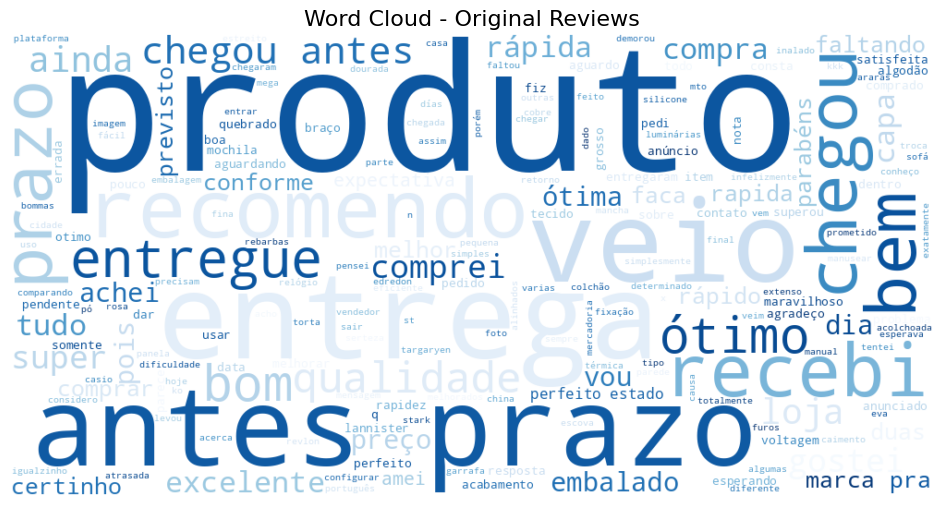

In [53]:
from wordcloud import WordCloud
from collections import Counter

# Word Cloud - Review Text
all_reviews = " ".join(
    result_df1["review_comment_message_clean"].dropna().astype(str)
)

wordcloud_reviews = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    colormap="Blues",
    max_words=200
).generate(all_reviews)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_reviews, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud - Original Reviews", fontsize=16)
plt.show()

**Result:**

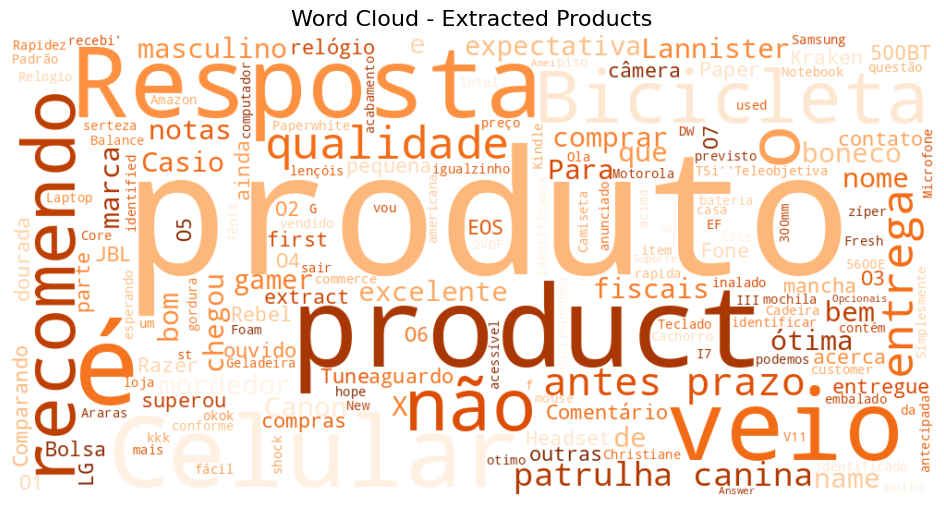

In [54]:
# Word Cloud - Extracted Products
# Flatten product lists into a single string
all_products = " ".join(
    [", ".join(prod) if isinstance(prod, list) else str(prod)
     for prod in result_df1["product_list_2"].dropna()]
)

wordcloud_products = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    colormap="Oranges",
    max_words=200
).generate(all_products)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_products, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud - Extracted Products", fontsize=16)
plt.show()

**Result:**

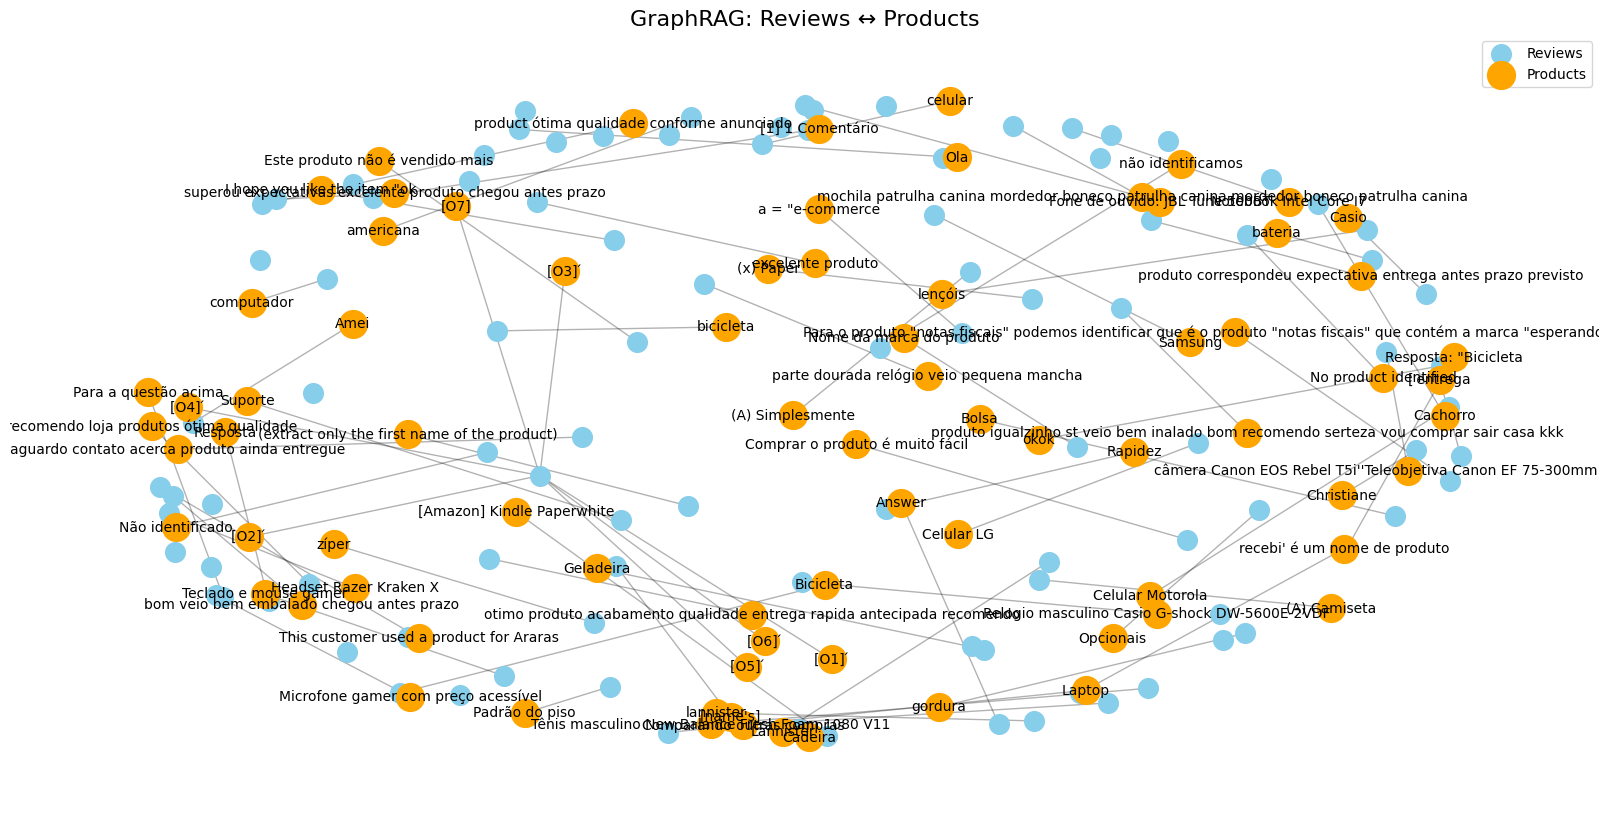

In [60]:
import networkx as nx

# Initialize graph
G = nx.Graph()

# Add nodes and edges from the sample DataFrame
for idx, row in result_df1.iterrows():
    review = f"Review {idx}"  # unique ID for each review
    products = row["product_list_2"]

    # Add review node
    G.add_node(review, type="review")

    # Add product nodes and connect them to review
    if isinstance(products, list):
        for p in products:
            if p:  # skip empty strings
                G.add_node(p, type="product")
                G.add_edge(review, p)

# Draw Graph

# Separate node types for coloring
review_nodes = [n for n, d in G.nodes(data=True) if d["type"] == "review"]
product_nodes = [n for n, d in G.nodes(data=True) if d["type"] == "product"]

plt.figure(figsize=(20.5, 10))
pos = nx.spring_layout(G, k=0.5, seed=42)

# Draw nodes
nx.draw_networkx_nodes(G, pos, nodelist=review_nodes, node_color="skyblue", node_size=200, label="Reviews")
nx.draw_networkx_nodes(G, pos, nodelist=product_nodes, node_color="orange", node_size=400, label="Products")

# Draw edges
nx.draw_networkx_edges(G, pos, alpha=0.3)

# Draw labels only for products (to avoid clutter)
nx.draw_networkx_labels(G, pos, labels={n: n for n in product_nodes}, font_size=10)

plt.title("GraphRAG: Reviews ↔ Products", fontsize=16)
plt.legend(scatterpoints=1)
plt.axis("off")
plt.show()

**Result:**

<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:110%; font-family:Pacifico; background-color:#0073e6; overflow:hidden"><b> Part 10 - LLM Embeddings</b></div>

In [68]:
# Define the LLM model (Sabia-7B from Maritaca AI)
model_name2 = "maritaca-ai/sabia-7b"

# Load the tokenizer for the model
tokenizer = AutoTokenizer.from_pretrained(model_name2)

# Load the model with GPU auto-mapping and mixed precision
model = AutoModelForCausalLM.from_pretrained(
    model_name2,
    device_map="auto",   # Automatically assign layers to GPU (if available)
    torch_dtype="auto"   # Select float16/float32 automatically based on hardware
)


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

In [62]:
def get_sabia_embedding(text: str) -> np.ndarray:
    """
    Generate an embedding vector for a given text using the Sabia-7B model.

    The embedding is computed by averaging the last hidden states
    of the model (mean pooling).

    Parameters
    ----------
    text : str
        Input text to embed.

    Returns
    -------
    np.ndarray
        Embedding vector (float32).
    """
    # Tokenize input text (truncate to max length of 128 tokens)
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=128
    )

    # Move tensors to the same device as the model (CPU/GPU)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    # Disable gradient computation for efficiency
    with torch.no_grad():
        outputs = model.model(
            input_ids=inputs["input_ids"],
            attention_mask=inputs.get("attention_mask"),
            output_hidden_states=True,
            return_dict=True
        )

        # Get the last hidden state (sequence length x hidden dimension)
        hidden_states = outputs.hidden_states[-1]

        # Mean pooling across tokens -> embedding vector
        embedding = (
            hidden_states.mean(dim=1)
            .squeeze()
            .cpu()
            .to(torch.float32)
            .numpy()
        )

    return embedding


In [63]:
## Sample embeddings with LLM + ML

# Take a random sample of 1000 reviews
tqdm.pandas()
sample_df = nlp_df.sample(n=100, random_state=42).reset_index(drop=True)

# Apply the embedding function to each review (with progress bar)
sample_df["llm_sabia_embedding"] = sample_df[
    "review_comment_message_clean"
].progress_apply(get_sabia_embedding)


100%|██████████| 1000/1000 [2:14:29<00:00,  8.07s/it] 


In [73]:
# Generate LLM embeddings for ML classification model
sample_df[
    [
        "review_comment_message_clean",
        "review_comment_message_clean_sentiment",
        "llm_sabia_embedding"
    ]
].head()

,review_comment_message_clean,review_comment_message_clean_sentiment,llm_sabia_embedding
0,entrega rapida,Neutral,"[-0.54296875, -0.375, -0.13574219, 2.0625, 0.0..."
1,produto bommas achei edredon bem grosso,Positive,"[-0.765625, -0.045654297, -0.050048828, 3.7187..."
2,produto chegou antes prazo determinado,Positive,"[-0.7109375, 0.18066406, 0.15429688, 4.625, 0...."
3,parte dourada relógio veio pequena mancha,Neutral,"[-1.3359375, 0.69140625, -0.75390625, 5.125, -..."
4,produto bom parece tipo eva bem grosso pensei ...,Positive,"[-1.7109375, -0.19921875, -0.203125, 5.65625, ..."


In [75]:
# Stack the embeddings into a 2D NumPy array (features)
X = np.vstack(sample_df["llm_sabia_embedding"].values)

# Extract the sentiment labels (target)
y = sample_df["review_comment_message_clean_sentiment"].values

# Split dataset into training and test sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [76]:
# Standardize the embeddings (important for Logistic Regression and other ML models)
scaler = StandardScaler()

# Fit on training data and transform both train and test sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Display the fitted scaler object
scaler

StandardScaler()

In [85]:
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm

# Encode labels (convert strings -> integers)
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

#
le

LabelEncoder()

<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:110%; font-family:Pacifico; background-color:#0073e6; overflow:hidden"><b> Part 11 - LLM Model machine learning </b></div>

In [99]:
# Define 10 ML Models
models = {
    
    "Logistic Regression": LogisticRegression(max_iter=500,
                                              class_weight="balanced",
                                              solver="lbfgs"),
    
    "Random Forest": RandomForestClassifier(n_estimators=200,
                                            max_depth=10,
                                            class_weight="balanced",
                                            random_state=42),
    "Naive Bayes": GaussianNB(),
    
    "Decision Tree": DecisionTreeClassifier(max_depth=10,
                                            class_weight="balanced",
                                            random_state=42),
    
    "XGBoost": XGBClassifier(eval_metric="mlogloss",
                             use_label_encoder=False,
                             random_state=42),
    
    "LightGBM": LGBMClassifier(class_weight="balanced",
                               random_state=42)
}

# Train & Evaluate Models
results = {}

for name, model in tqdm(models.items(), desc="Training Models"):
    # Train
    model.fit(X_train_scaled, y_train_enc)

    # Predict
    y_pred = model.predict(X_test_scaled)

    # Decode predictions back to original labels (optional)
    y_pred_labels = le.inverse_transform(y_pred)

    # Accuracy and classification report
    acc = accuracy_score(y_test_enc, y_pred)
    report = classification_report(
        y_test_enc, y_pred, digits=4, output_dict=True
    )

    # Save results
    results[name] = {
        "accuracy": acc,
        "precision_macro": report["macro avg"]["precision"],
        "recall_macro": report["macro avg"]["recall"],
        "f1_macro": report["macro avg"]["f1-score"]
    }

# Results
results_df = pd.DataFrame(results).T.sort_values(by="f1_macro", ascending=False)
print("\n Model Comparison")
results_df

Training Models:  83%|████████▎ | 5/6 [00:54<00:14, 14.87s/it]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.130099 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 866217
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 4096
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


Training Models: 100%|██████████| 6/6 [01:46<00:00, 17.81s/it]


 Model Comparison


,accuracy,precision_macro,recall_macro,f1_macro
Logistic Regression,0.805,0.787635,0.745848,0.763440
XGBoost,0.770,0.793591,0.636580,0.660129
LightGBM,0.750,0.705288,0.618137,0.635568
Random Forest,0.730,0.750703,0.601176,0.632297
Naive Bayes,0.640,0.602933,0.670383,0.602498
Decision Tree,0.580,0.509945,0.487250,0.494769


<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:110%; font-family:Pacifico; background-color:#0073e6; overflow:hidden"><b> Part 12 - LLM Machine Learning Model (Metrics and Evaluation)</b></div>

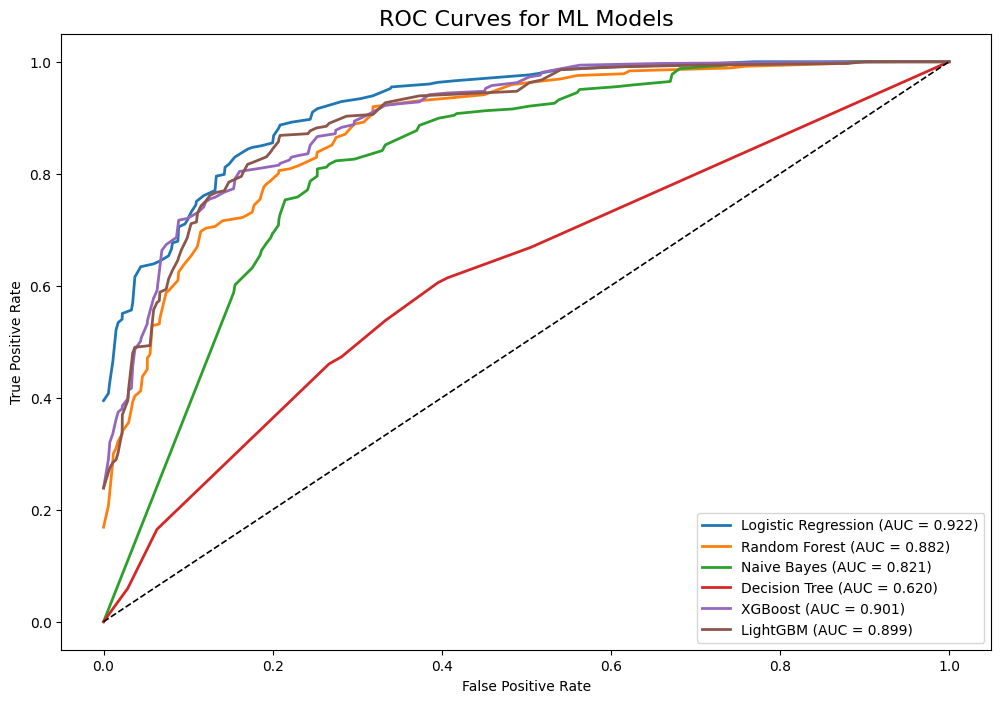

In [96]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle

## ROC Curve for Multiple Models

# Binarize labels (in case of multiclass classification)
classes = np.unique(y_train)
y_test_bin = label_binarize(y_test, classes=classes)

# Color palette for multiple curves
colors = cycle(sns.color_palette("tab10", len(models)))

plt.figure(figsize=(12, 8))

for (name, model), color in zip(models.items(), colors):
    # Some models may not have predict_proba, so use decision_function as fallback
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_scaled)
    else:
        y_score = model.decision_function(X_test_scaled)

    # Handle binary vs multiclass
    if len(classes) == 2:
        fpr, tpr, _ = roc_curve(y_test, y_score[:, 1])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=color, lw=2,
                 label=f"{name} (AUC = {roc_auc:.3f})")
    else:
        # Average ROC curve for multiclass
        fpr, tpr, roc_auc = {}, {}, {}
        for i in range(len(classes)):
            fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])

        # Macro-average ROC
        all_fpr = np.unique(np.concatenate([fpr[i] for i in range(len(classes))]))
        mean_tpr = np.zeros_like(all_fpr)
        for i in range(len(classes)):
            mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
        mean_tpr /= len(classes)

        roc_auc_macro = auc(all_fpr, mean_tpr)
        plt.plot(all_fpr, mean_tpr, color=color, lw=2,
                 label=f"{name} (AUC = {roc_auc_macro:.3f})")

# Plot reference line
plt.plot([0, 1], [0, 1], "k--", lw=1.2)

plt.title("ROC Curves for ML Models", fontsize=16)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right", fontsize=10)
plt.show()

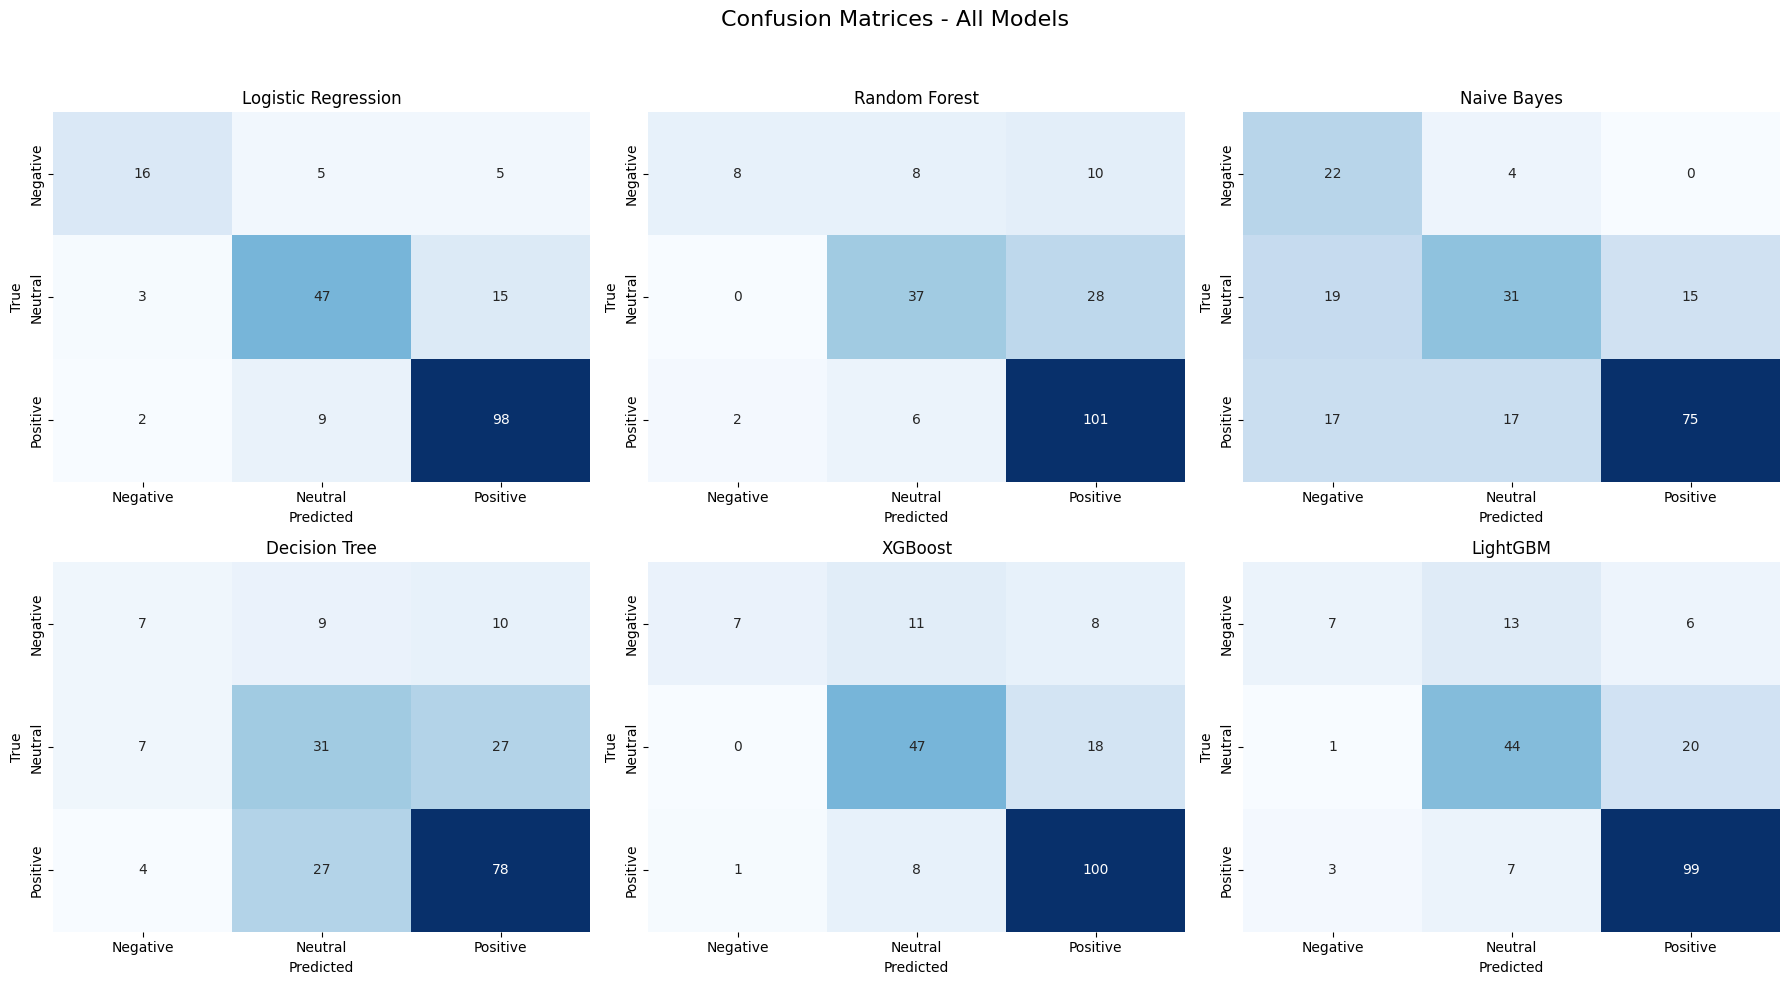

In [100]:
from sklearn.metrics import confusion_matrix

# Confusion Matrices for All Models
n_models = len(models)
n_cols = 3 
n_rows = (n_models + n_cols - 1) // n_cols  

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
axes = axes.flatten()

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test_scaled)
    y_pred_labels = le.inverse_transform(y_pred)

    cm = confusion_matrix(y_test, y_pred_labels, labels=le.classes_)

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                ax=ax, xticklabels=le.classes_, yticklabels=le.classes_)

    ax.set_title(name, fontsize=12)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

# Remove subplots extras, se houver
for ax in axes[len(models):]:
    ax.axis("off")

plt.suptitle("Confusion Matrices - All Models", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [116]:
from sklearn.metrics import classification_report

# Classification Reports for All Models
for name, model in models.items():
    print("=" * 80)
    print(f" Classification Report - {name}")
    print("=" * 80)

    # Predict (encoded -> decode back to original labels)
    y_pred = model.predict(X_test_scaled)
    y_pred_labels = le.inverse_transform(y_pred)  # convert integers back to strings

    # Generate classification report (string format, não DataFrame)
    report = classification_report(
        y_test,                 # true labels (strings)
        y_pred_labels,          # predicted labels (strings)
        labels=le.classes_,     # keep class order consistent
        digits=4
    )

    print(report)
    print("\n")

 Classification Report - Logistic Regression
              precision    recall  f1-score   support

    Negative     0.7619    0.6154    0.6809        26
     Neutral     0.7705    0.7231    0.7460        65
    Positive     0.8305    0.8991    0.8634       109

    accuracy                         0.8050       200
   macro avg     0.7876    0.7458    0.7634       200
weighted avg     0.8021    0.8050    0.8015       200



 Classification Report - Random Forest
              precision    recall  f1-score   support

    Negative     0.8000    0.3077    0.4444        26
     Neutral     0.7255    0.5692    0.6379        65
    Positive     0.7266    0.9266    0.8145       109

    accuracy                         0.7300       200
   macro avg     0.7507    0.6012    0.6323       200
weighted avg     0.7358    0.7300    0.7090       200



 Classification Report - Naive Bayes
              precision    recall  f1-score   support

    Negative     0.3793    0.8462    0.5238        26
    

In [115]:
from sklearn.metrics import classification_report, accuracy_score

# Train & Evaluate Models
results = {}

for name, model in tqdm(models.items(), desc="Training Models"):

    # Predict
    y_pred = model.predict(X_test_scaled)

    # Accuracy and classification report
    acc = accuracy_score(y_test_enc, y_pred)
    report = classification_report(y_test_enc,
                                   y_pred,
                                   labels=np.unique(y_test_enc),
                                   digits=4,
                                   output_dict=True)

    # Save results (all macro metrics + accuracy)
    results[name] = {
        "accuracy": acc,
        "precision_macro": report["macro avg"]["precision"],
        "recall_macro": report["macro avg"]["recall"],
        "f1_macro": report["macro avg"]["f1-score"]
    }

# Convert results to DataFrame
results_df = (
    pd.DataFrame(results)
    .T
    .reset_index()
    .rename(columns={"index": "Model"})
    .sort_values(by="f1_macro", ascending=False)
)

top_mask = results_df["f1_macro"] == results_df["f1_macro"].max()

def highlight_all_winners(df: pd.DataFrame) -> pd.DataFrame:
    mask = pd.DataFrame("", index=df.index, columns=df.columns)
    mask.loc[top_mask, :] = "background-color: #FFE066; color: black;"
    return mask

styled_results = results_df.style.apply(highlight_all_winners, axis=None).format(
    {"accuracy": "{:.4f}", "precision_macro": "{:.4f}",
     "recall_macro": "{:.4f}", "f1_macro": "{:.4f}"}
)

styled_results

Training Models: 100%|██████████| 6/6 [00:00<00:00, 82.56it/s]


,Model,accuracy,precision_macro,recall_macro,f1_macro
0,Logistic Regression,0.8050,0.7876,0.7458,0.7634
4,XGBoost,0.7700,0.7936,0.6366,0.6601
5,LightGBM,0.7500,0.7053,0.6181,0.6356
1,Random Forest,0.7300,0.7507,0.6012,0.6323
2,Naive Bayes,0.6400,0.6029,0.6704,0.6025
3,Decision Tree,0.5800,0.5099,0.4873,0.4948


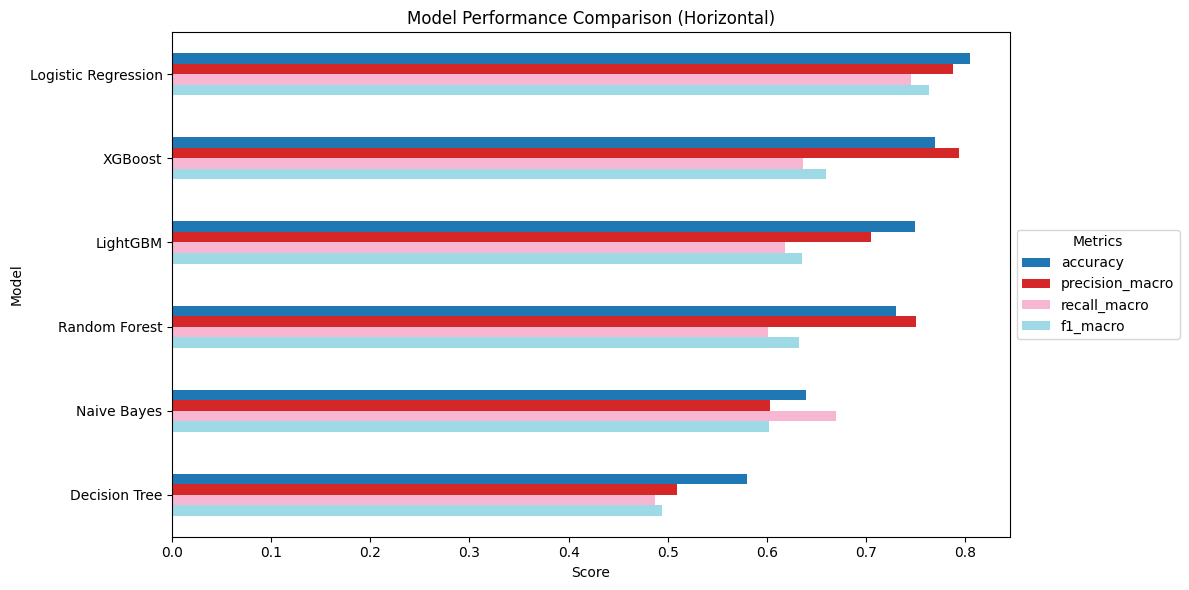

In [121]:
# Horizontal bar chart for model comparison
ax = results_df.plot(
    x="Model",
    y=["accuracy", "precision_macro", "recall_macro", "f1_macro"],
    kind="barh",         # horizontal format
    figsize=(12, 6),
    colormap="tab20"
)

plt.title("Model Performance Comparison (Horizontal)")
plt.xlabel("Score")
plt.ylabel("Model")

# Place legend outside the plot (to the right)
plt.legend(
    loc="center left",
    bbox_to_anchor=(1.0, 0.5),   # shift legend outside
    title="Metrics"
)

# Invert y-axis so the best model appears on top
plt.gca().invert_yaxis()

# Adjust layout to avoid clipping
plt.tight_layout()

# Display plot
plt.show()